# Natural Language Processing

In [2]:
# LOAD NLP-READY MANUALLY VALIDATED DATASET

import pandas as pd
import numpy as np
import re

from blended_learning.config.settings import settings

df = pd.read_csv(
    settings.root / "data" / "processed" / "nlp_translated_responses.csv",
    encoding="utf-8-sig"
)

print(f"NLP-ready dataset loaded: {df.shape}")
display(df.head())

NLP-ready dataset loaded: (567, 10)


,student_id,open_strengths,open_challenges_suggestions,student_segment,student_segment_label,cluster_label,open_strengths_lang,open_challenges_suggestions_lang,open_strengths_en,open_challenges_suggestions_en
0,e20210686,Nothing,Nothing,2,Moderately Engaged (Passive) Learners,Highly Engaged (Active) Learners,en,en,Nothing,Nothing
1,e20241146,"Very good, excellent","No big challenge, i’m the best",1,Highly Engaged (Active) Learners,Moderately Engaged (Passive) Learners,en,en,"Very good, excellent","No big challenge, i’m the best"
2,e20240609,Will try hard,Lack of self-discipline,1,Highly Engaged (Active) Learners,Moderately Engaged (Passive) Learners,en,en,Will try hard,Lack of self-discipline
3,e20240542,getting more experience,Discipline on daily studying,2,Moderately Engaged (Passive) Learners,Highly Engaged (Active) Learners,en,en,getting more experience,Discipline on daily studying
4,e20220287,Student could retrieve the lesson once they wa...,Add Ai assistance,2,Moderately Engaged (Passive) Learners,Highly Engaged (Active) Learners,en,en,Student could retrieve the lesson once they wa...,Add Ai assistance


In [4]:

# BASIC TEXT CLEANING

import re
import pandas as pd

def clean_basic_text(text):
    if pd.isna(text):
        return ""

    text = str(text).lower().strip()
    text = re.sub(r"\s+", " ", text)

    text = text.replace("face to face", "in_person")
    text = text.replace("face-to-face", "in_person")
    text = text.replace("face face", "in_person")

    text = text.replace("self study", "self_study")
    text = text.replace("self studying", "self_study")
    text = text.replace("self learning", "self_learning")
    text = text.replace("time management", "time_management")
    text = text.replace("internet connection", "internet_connection")
    text = text.replace("internet access", "internet_access")
    text = text.replace("technical issues", "technical_issues")
    text = text.replace("online learning", "online_learning")
    text = text.replace("blended learning", "blended_learning")
    text = text.replace("saving time", "save_time")

    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [8]:
# Apply basic cleaning to the relevant columns
df["open_strengths_clean"] = (
    df["open_strengths_en"]
    .apply(clean_basic_text)
)

df["open_challenges_clean"] = (
    df["open_challenges_suggestions_en"]
    .apply(clean_basic_text)
)

## CUSTOM STOPWORDS FOR TF-IDF

In [9]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Merge sklearn and the custom words in the config.json

custom_stopwords = set(ENGLISH_STOP_WORDS).union(settings.custom_stopwords)

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# Expand multi-word stopwords into sklearn-tokenized single words
analyzer = CountVectorizer().build_analyzer()

expanded_stopwords = set(custom_stopwords)

for word in custom_stopwords:
    expanded_stopwords.update(analyzer(word))

custom_stopwords = sorted(expanded_stopwords)

In [11]:
# TF-IDF keyword extraction function

def get_top_tfidf_keywords(df, text_col, top_n=20, ngram_range=(1, 2)):
    texts = df[text_col].fillna("").astype(str)
    texts = texts[texts.str.strip() != ""]

    vectorizer = TfidfVectorizer(
        stop_words=list(custom_stopwords),
        ngram_range=ngram_range,
        min_df=2,
        max_df=0.90
    )

    tfidf_matrix = vectorizer.fit_transform(texts)
    feature_names = vectorizer.get_feature_names_out()
    scores = tfidf_matrix.sum(axis=0).A1

    keyword_df = pd.DataFrame({
        "keyword": feature_names,
        "tfidf_score": scores
    })

    keyword_df["keyword"] = (
        keyword_df["keyword"]
        .str.replace("_", " ", regex=False)
    )

    keyword_df = keyword_df.sort_values(
        by="tfidf_score",
        ascending=False
    ).head(top_n)

    return keyword_df


## BIGRAM TF-IDF KEYWORD EXTRACTION


In [13]:
strengths_keywords = get_top_tfidf_keywords(
    df,
    "open_strengths_clean",
    top_n=20,
    ngram_range=(2, 2)
)

challenges_keywords = get_top_tfidf_keywords(
    df,
    "open_challenges_clean",
    top_n=20,
    ngram_range=(2, 2)
)

print("Top TF-IDF keywords and phrases: strengths")
display(strengths_keywords)

print("Top TF-IDF keywords and phrases: challenges/suggestions")
display(challenges_keywords)

Top TF-IDF keywords and phrases: strengths


,keyword,tfidf_score
91,learn pace,10.011461
1,access materials,9.058368
37,digital skills,6.312746
126,review anytime,5.677180
100,materials anytime,4.474426
50,flexibility convenience,4.350860
10,ask questions,4.179534
57,flexibility review,4.093067
54,flexibility learn,3.737879
47,flexibility access,3.645520


Top TF-IDF keywords and phrases: challenges/suggestions


,keyword,tfidf_score
68,internet issues,11.441964
188,unstable internet connection,8.390665
95,lack motivation,7.993118
5,ask questions,6.853384
67,internet issue,6.288585
93,lack interaction,6.199208
124,pay attention,5.590512
20,difficulty staying,5.427419
81,internet connection difficulty,5.183727
179,technical problems,4.905745


The TF-IDF score represents the relative importance of a keyword or phrase within the dataset. A higher score indicates that the term appears frequently in students’ responses while remaining relatively unique, making it a strong indicator of key themes.

In [14]:
# MAP THEMES TO SYSTEM-READY DEFINITIONS
strength_theme_map = settings.strength_theme_map

challenge_theme_map = settings.challenge_theme_map


In [15]:
def build_theme_summary(keyword_df, theme_map):
    rows = []

    for theme, keywords in theme_map.items():
        matched = keyword_df[keyword_df["keyword"].isin(keywords)]

        if not matched.empty:
            rows.append({
                "theme": theme,
                "keywords": ", ".join(matched["keyword"]),
                "total_score": matched["tfidf_score"].sum(),
                "keyword_count": len(matched)
            })

    if len(rows) == 0:
        return pd.DataFrame(
            columns=["theme", "keywords", "total_score", "keyword_count"]
        )

    return (
        pd.DataFrame(rows)
        .sort_values(by="total_score", ascending=False)
        .reset_index(drop=True)
    )

In [16]:
strength_theme_summary = build_theme_summary(
    strengths_keywords, strength_theme_map
)

challenge_theme_summary = build_theme_summary(
    challenges_keywords, challenge_theme_map
)

display(strength_theme_summary)
display(challenge_theme_summary)

,theme,keywords,total_score,keyword_count
0,Digital Skills Development,"digital skills, digital tools",9.762317,2
1,Access to Learning Materials,access materials,9.058368,1
2,Student Engagement,ask questions,4.179534,1
3,Flexibility & Time Management,flexible schedule,2.707107,1


,theme,keywords,total_score,keyword_count
0,Internet & Technical Issues,"internet issues, internet issue, technical pro...",38.559206,7
1,Motivation & Self-Discipline,"lack motivation, pay attention, lack discipline",17.212147,3
2,Interaction & Communication,"ask questions, lack interaction",13.052592,2
3,Learning Difficulty & Clarity,"difficulty understanding, unclear instructions",7.431644,2


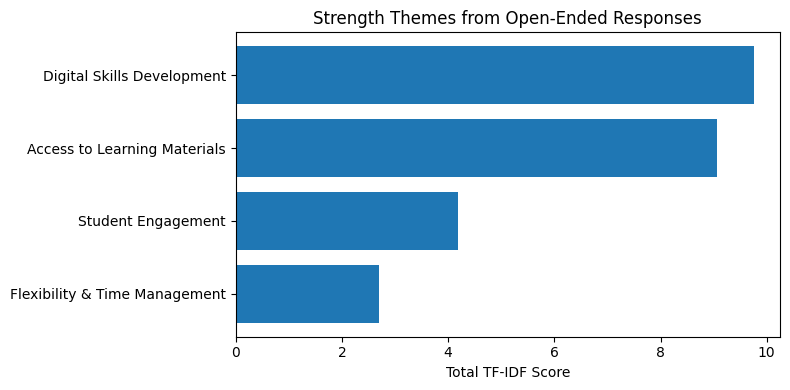

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.barh(
    strength_theme_summary["theme"],
    strength_theme_summary["total_score"]
)
plt.xlabel("Total TF-IDF Score")
plt.title("Strength Themes from Open-Ended Responses")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

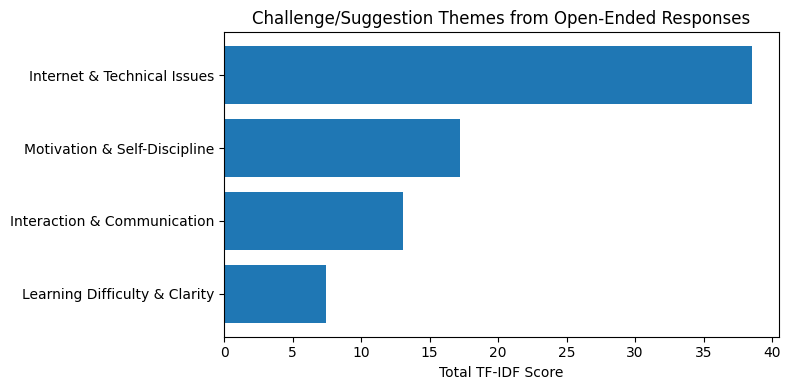

In [18]:
plt.figure(figsize=(8, 4))
plt.barh(
    challenge_theme_summary["theme"],
    challenge_theme_summary["total_score"]
)
plt.xlabel("Total TF-IDF Score")
plt.title("Challenge/Suggestion Themes from Open-Ended Responses")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [19]:
#  mapping themes to recommendation categories
theme_to_recommendation_map = settings.theme_to_recommendation_map


In [20]:
def get_student_tags(keywords):
    tags = set()

    for theme, kw_list in {**strength_theme_map, **challenge_theme_map}.items():
        if any(k in keywords for k in kw_list):
            tags.add(theme_to_recommendation_map.get(theme))

    return list(tags)

# Tie themes with clusters


In [21]:
# =========================================================
# CLUSTER-BASED THEME EXTRACTION
# =========================================================

cluster_col = "student_segment"
cluster_label_col = "student_segment_label"

def build_cluster_theme_summary(
    df,
    cluster_col,
    cluster_label_col,
    text_col,
    theme_map,
    top_n_keywords=30
):
    all_rows = []

    for cluster in sorted(df[cluster_col].dropna().unique()):
        subset = df[df[cluster_col] == cluster]

        if subset.shape[0] < 2:
            continue

        cluster_label = subset[cluster_label_col].iloc[0]

        keyword_df = get_top_tfidf_keywords(
            subset,
            text_col,
            top_n=top_n_keywords,
            ngram_range=(2, 2)
        )

        theme_summary = build_theme_summary(keyword_df, theme_map)

        for _, row in theme_summary.iterrows():
            all_rows.append({
            "cluster": cluster,
            "cluster_label": cluster_label,
            "theme": row["theme"],
            "keywords": row["keywords"],
            "total_score": row["total_score"],
            "keyword_count": row["keyword_count"],
            "n_students": subset.shape[0]
    })

    return pd.DataFrame(all_rows)

In [22]:
cluster_strength_themes = build_cluster_theme_summary(
    df,
    cluster_col,
    cluster_label_col,
    "open_strengths_clean",
    strength_theme_map
)

display(cluster_strength_themes)

,cluster,cluster_label,theme,keywords,total_score,keyword_count,n_students
0,1,Highly Engaged (Active) Learners,Access to Learning Materials,"access materials, recorded videos",9.680519,2,345
1,1,Highly Engaged (Active) Learners,Digital Skills Development,"digital skills, digital tools",6.767417,2,345
2,1,Highly Engaged (Active) Learners,Student Engagement,ask questions,3.833473,1,345
3,1,Highly Engaged (Active) Learners,Flexibility & Time Management,flexible schedule,2.000000,1,345
4,2,Moderately Engaged (Passive) Learners,Digital Skills Development,digital skills,3.509400,1,222
5,2,Moderately Engaged (Passive) Learners,Access to Learning Materials,access materials,1.968374,1,222
6,2,Moderately Engaged (Passive) Learners,Flexibility & Time Management,learn anytime,1.544453,1,222


In [23]:
cluster_challenge_themes = build_cluster_theme_summary(
    df,
    cluster_col,
    cluster_label_col,
    "open_challenges_clean",
    challenge_theme_map
)

display(cluster_challenge_themes)

,cluster,cluster_label,theme,keywords,total_score,keyword_count,n_students
0,1,Highly Engaged (Active) Learners,Internet & Technical Issues,"internet issues, internet issue, internet prob...",16.471394,5,345
1,1,Highly Engaged (Active) Learners,Interaction & Communication,"ask questions, lack interaction, interactive a...",13.629954,4,345
2,1,Highly Engaged (Active) Learners,Motivation & Self-Discipline,"pay attention, lack motivation, lack discipline",10.450370,3,345
3,1,Highly Engaged (Active) Learners,Learning Difficulty & Clarity,"difficulty understanding, unclear instructions...",7.357547,3,345
4,2,Moderately Engaged (Passive) Learners,Internet & Technical Issues,"internet issues, technical problems, internet ...",24.544175,8,222
5,2,Moderately Engaged (Passive) Learners,Interaction & Communication,"lack interaction, limited interaction, ask que...",7.849688,4,222
6,2,Moderately Engaged (Passive) Learners,Motivation & Self-Discipline,"lack motivation, pay attention",6.989567,2,222
7,2,Moderately Engaged (Passive) Learners,Learning Difficulty & Clarity,"unclear instructions, difficulty understanding",3.413182,2,222


In [24]:
display(
    cluster_strength_themes.sort_values(
        ["cluster", "total_score"],
        ascending=[True, False]
    )
)

display(
    cluster_challenge_themes.sort_values(
        ["cluster", "total_score"],
        ascending=[True, False]
    )
)

,cluster,cluster_label,theme,keywords,total_score,keyword_count,n_students
0,1,Highly Engaged (Active) Learners,Access to Learning Materials,"access materials, recorded videos",9.680519,2,345
1,1,Highly Engaged (Active) Learners,Digital Skills Development,"digital skills, digital tools",6.767417,2,345
2,1,Highly Engaged (Active) Learners,Student Engagement,ask questions,3.833473,1,345
3,1,Highly Engaged (Active) Learners,Flexibility & Time Management,flexible schedule,2.000000,1,345
4,2,Moderately Engaged (Passive) Learners,Digital Skills Development,digital skills,3.509400,1,222
5,2,Moderately Engaged (Passive) Learners,Access to Learning Materials,access materials,1.968374,1,222
6,2,Moderately Engaged (Passive) Learners,Flexibility & Time Management,learn anytime,1.544453,1,222


,cluster,cluster_label,theme,keywords,total_score,keyword_count,n_students
0,1,Highly Engaged (Active) Learners,Internet & Technical Issues,"internet issues, internet issue, internet prob...",16.471394,5,345
1,1,Highly Engaged (Active) Learners,Interaction & Communication,"ask questions, lack interaction, interactive a...",13.629954,4,345
2,1,Highly Engaged (Active) Learners,Motivation & Self-Discipline,"pay attention, lack motivation, lack discipline",10.450370,3,345
3,1,Highly Engaged (Active) Learners,Learning Difficulty & Clarity,"difficulty understanding, unclear instructions...",7.357547,3,345
4,2,Moderately Engaged (Passive) Learners,Internet & Technical Issues,"internet issues, technical problems, internet ...",24.544175,8,222
5,2,Moderately Engaged (Passive) Learners,Interaction & Communication,"lack interaction, limited interaction, ask que...",7.849688,4,222
6,2,Moderately Engaged (Passive) Learners,Motivation & Self-Discipline,"lack motivation, pay attention",6.989567,2,222
7,2,Moderately Engaged (Passive) Learners,Learning Difficulty & Clarity,"unclear instructions, difficulty understanding",3.413182,2,222


Excellent — this is exactly the result you need. Now you can interpret **how the two student clusters differ**.

## Key findings from your cluster-based themes

### Cluster 1: Moderately Engaged (Passive) Learners

**Strengths**
Their strongest positive theme is:

> **Access to Learning Materials**
> total score = 11.02

This means passive/moderately engaged students mainly value blended learning because they can access and review materials anytime.

Their next themes are:

> **Flexibility & Time Management**
> total score = 6.04

> **Digital Skills Development**
> total score = 4.76

So this group benefits from flexible learning, but their engagement-related strength is weaker:

> **Student Engagement**
> total score = 1.46

This makes sense because they are labeled as moderately engaged/passive learners.

---

### Cluster 2: Highly Engaged (Active) Learners

**Strengths**
Their strongest positive theme is also:

> **Access to Learning Materials**
> total score = 12.42

But compared with Cluster 1, Cluster 2 shows stronger results in:

> **Flexibility & Time Management**
> total score = 8.54

> **Digital Skills Development**
> total score = 5.56

> **Student Engagement**
> total score = 3.93

This means highly engaged students are not only using materials, but also benefiting more from flexibility, digital tools, and active participation.

---

## Challenge comparison

### Cluster 1 challenges

The biggest challenge is:

> **Internet & Technical Issues**
> total score = 15.45

Other challenges:

> **Motivation & Self-Discipline**
> total score = 6.00

> **Learning Difficulty & Clarity**
> total score = 4.61

> **Interaction & Communication**
> total score = 3.97

For Cluster 1, the main issue is technical access, followed by motivation.

---

### Cluster 2 challenges

The biggest challenge is also:

> **Internet & Technical Issues**
> total score = 15.59

But Cluster 2 has stronger challenge scores in:

> **Learning Difficulty & Clarity**
> total score = 9.97

> **Interaction & Communication**
> total score = 9.52

> **Motivation & Self-Discipline**
> total score = 8.53

This is interesting. Even though they are highly engaged, they still report many challenges. This may mean they are more active, more aware of learning problems, and more likely to express detailed feedback.

---

## Thesis interpretation

You can write:

> The cluster-based theme analysis shows that both student segments identified access to learning materials as the main strength of blended learning. However, highly engaged learners showed stronger associations with flexibility, digital skills development, and student engagement, suggesting that active learners are better able to take advantage of blended learning opportunities.
>
> In terms of challenges, both clusters reported internet and technical issues as the dominant concern. However, highly engaged learners also showed stronger concern with learning clarity, interaction, and motivation. This suggests that active learners may be more reflective and more likely to identify specific barriers affecting their learning experience.
>
> Meanwhile, moderately engaged learners showed weaker engagement-related themes, indicating that this group may require more structured support, motivation strategies, and interaction opportunities.

## How this supports your recommendation system

Use this mapping:

| Cluster                                | Main needs                                     | Suggested recommendation                                                                                        |
| -------------------------------------- | ---------------------------------------------- | --------------------------------------------------------------------------------------------------------------- |
| Cluster 1: Moderately Engaged Learners | Motivation, structure, interaction             | Provide reminders, weekly learning plans, short guided activities, and more teacher check-ins                   |
| Cluster 2: Highly Engaged Learners     | Better clarity, interaction, technical support | Provide advanced learning materials, clear instructions, interactive activities, and reliable technical support |

Your result is strong because it connects:

```text
Cluster profile → NLP themes → student needs → recommendation rules
```


# Visualize most important keywords

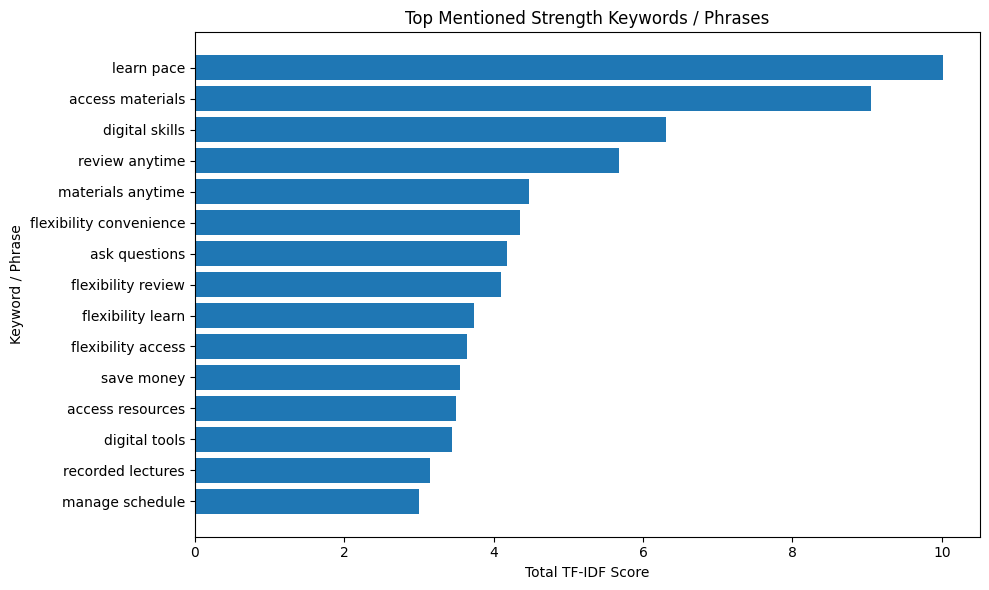

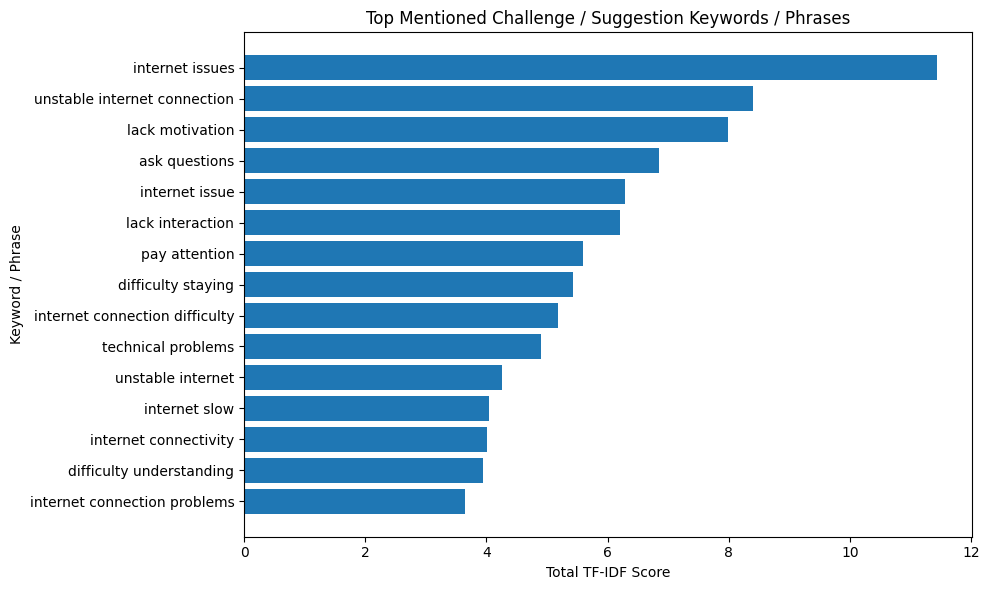

In [25]:
# =========================================================
# VISUALIZE TOP TF-IDF KEYWORDS / PHRASES
# =========================================================

import matplotlib.pyplot as plt
import seaborn as sns

def plot_top_keywords(keyword_df, title, top_n=15):
    plot_df = (
        keyword_df
        .sort_values("tfidf_score", ascending=False)
        .head(top_n)
        .sort_values("tfidf_score", ascending=True)
    )

    plt.figure(figsize=(10, 6))
    plt.barh(plot_df["keyword"], plot_df["tfidf_score"])
    plt.xlabel("Total TF-IDF Score")
    plt.ylabel("Keyword / Phrase")
    plt.title(title)
    plt.tight_layout()
    plt.show()


plot_top_keywords(
    strengths_keywords,
    "Top Mentioned Strength Keywords / Phrases",
    top_n=15
)

plot_top_keywords(
    challenges_keywords,
    "Top Mentioned Challenge / Suggestion Keywords / Phrases",
    top_n=15
)

# Visualize most important themes

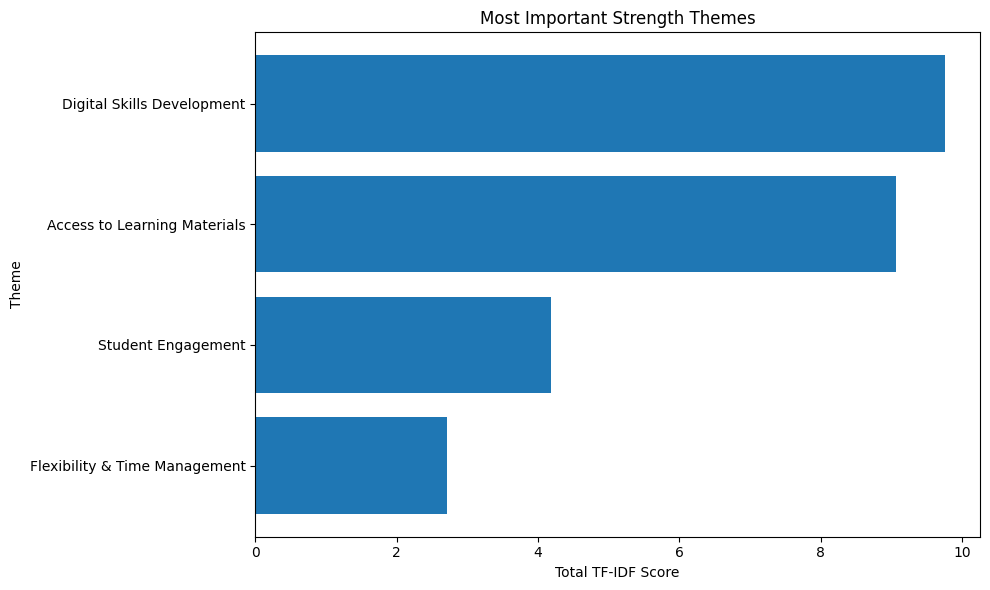

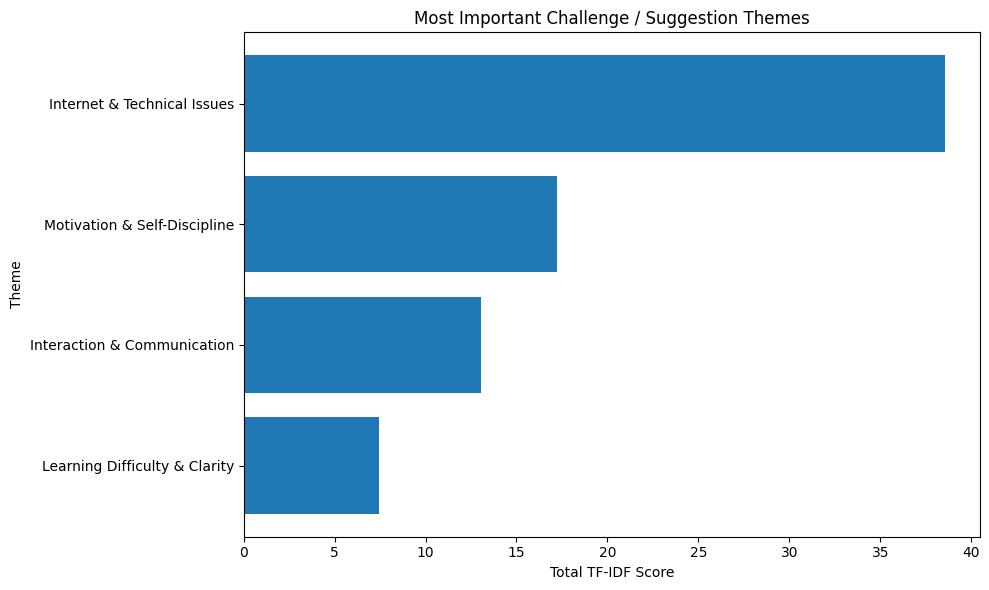

In [26]:
# =========================================================
# VISUALIZE TOP THEMES
# =========================================================

def plot_theme_summary(theme_summary, title):
    if theme_summary.empty:
        print(f"No theme data available for: {title}")
        return

    plot_df = theme_summary.sort_values("total_score", ascending=True)

    plt.figure(figsize=(10, 6))
    plt.barh(plot_df["theme"], plot_df["total_score"])
    plt.xlabel("Total TF-IDF Score")
    plt.ylabel("Theme")
    plt.title(title)
    plt.tight_layout()
    plt.show()


plot_theme_summary(
    strength_theme_summary,
    "Most Important Strength Themes"
)

plot_theme_summary(
    challenge_theme_summary,
    "Most Important Challenge / Suggestion Themes"
)

In [27]:
# =========================================================
# CLUSTER-BASED KEYWORD EXTRACTION
# =========================================================

def build_cluster_keyword_summary(
    df,
    cluster_col,
    cluster_label_col,
    text_col,
    top_n_keywords=15,
    ngram_range=(2, 2)
):
    all_rows = []

    for cluster in sorted(df[cluster_col].dropna().unique()):
        subset = df[df[cluster_col] == cluster]

        if subset.shape[0] < 2:
            continue

        cluster_label = subset[cluster_label_col].iloc[0]

        keyword_df = get_top_tfidf_keywords(
            subset,
            text_col,
            top_n=top_n_keywords,
            ngram_range=ngram_range
        )

        for _, row in keyword_df.iterrows():
            all_rows.append({
                "cluster": cluster,
                "cluster_label": cluster_label,
                "keyword": row["keyword"],
                "tfidf_score": row["tfidf_score"],
                "n_students": subset.shape[0],
                "response_type": text_col
            })

    return pd.DataFrame(all_rows)


cluster_strength_keywords = build_cluster_keyword_summary(
    df,
    cluster_col="student_segment",
    cluster_label_col="student_segment_label",
    text_col="open_strengths_clean",
    top_n_keywords=15,
    ngram_range=(2, 2)
)

cluster_challenge_keywords = build_cluster_keyword_summary(
    df,
    cluster_col="student_segment",
    cluster_label_col="student_segment_label",
    text_col="open_challenges_clean",
    top_n_keywords=15,
    ngram_range=(2, 2)
)

display(cluster_strength_keywords)
display(cluster_challenge_keywords)

,cluster,cluster_label,keyword,tfidf_score,n_students,response_type
0,1,Highly Engaged (Active) Learners,access materials,7.680519,345,open_strengths_clean
1,1,Highly Engaged (Active) Learners,learn pace,5.775947,345,open_strengths_clean
2,1,Highly Engaged (Active) Learners,review anytime,4.256477,345,open_strengths_clean
3,1,Highly Engaged (Active) Learners,ask questions,3.833473,345,open_strengths_clean
4,1,Highly Engaged (Active) Learners,digital skills,3.557882,345,open_strengths_clean
5,1,Highly Engaged (Active) Learners,materials anytime,3.427396,345,open_strengths_clean
6,1,Highly Engaged (Active) Learners,recorded lectures,3.257332,345,open_strengths_clean
7,1,Highly Engaged (Active) Learners,digital tools,3.209535,345,open_strengths_clean
8,1,Highly Engaged (Active) Learners,flexibility convenience,3.099832,345,open_strengths_clean
9,1,Highly Engaged (Active) Learners,flexibility learn,2.860338,345,open_strengths_clean


,cluster,cluster_label,keyword,tfidf_score,n_students,response_type
0,1,Highly Engaged (Active) Learners,internet issues,6.422813,345,open_challenges_clean
1,1,Highly Engaged (Active) Learners,ask questions,5.795531,345,open_challenges_clean
2,1,Highly Engaged (Active) Learners,unstable internet connection,5.406403,345,open_challenges_clean
3,1,Highly Engaged (Active) Learners,internet connection difficulty,4.073501,345,open_challenges_clean
4,1,Highly Engaged (Active) Learners,difficulty staying,4.024033,345,open_challenges_clean
5,1,Highly Engaged (Active) Learners,pay attention,4.000000,345,open_challenges_clean
6,1,Highly Engaged (Active) Learners,lack interaction,3.681053,345,open_challenges_clean
7,1,Highly Engaged (Active) Learners,lack motivation,3.478371,345,open_challenges_clean
8,1,Highly Engaged (Active) Learners,difficulty understanding,3.149762,345,open_challenges_clean
9,1,Highly Engaged (Active) Learners,internet issue,3.000000,345,open_challenges_clean


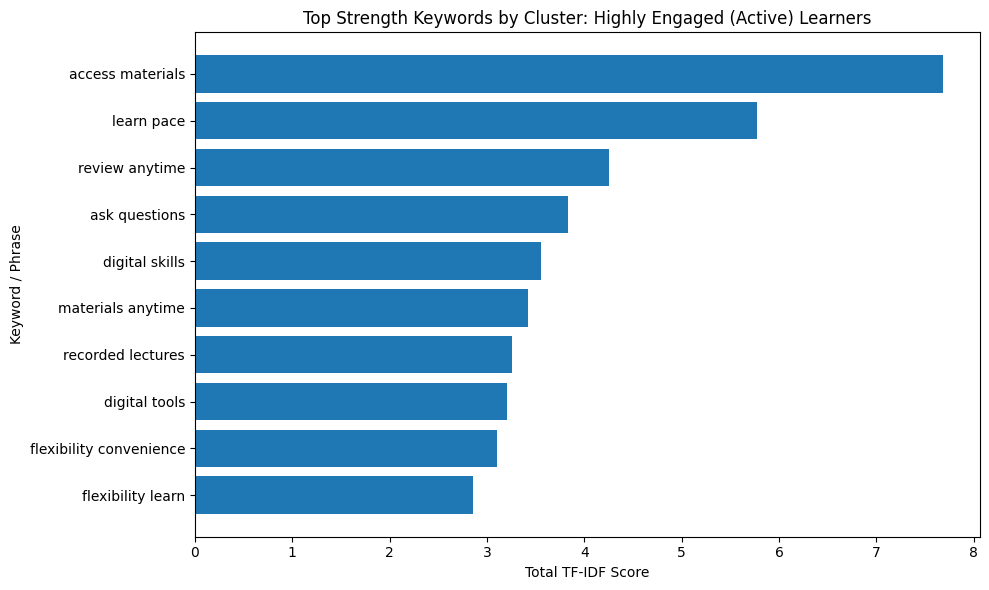

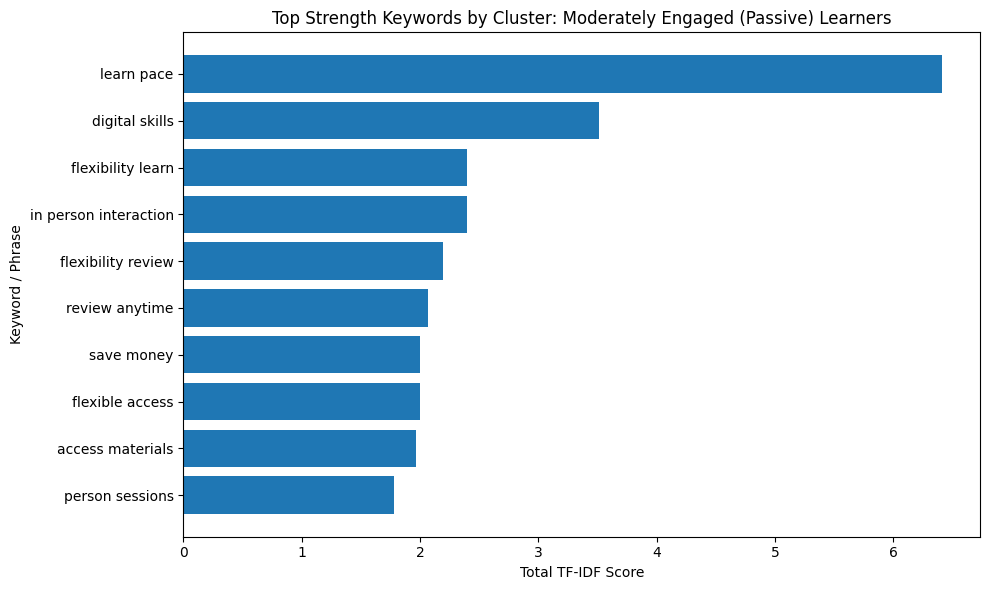

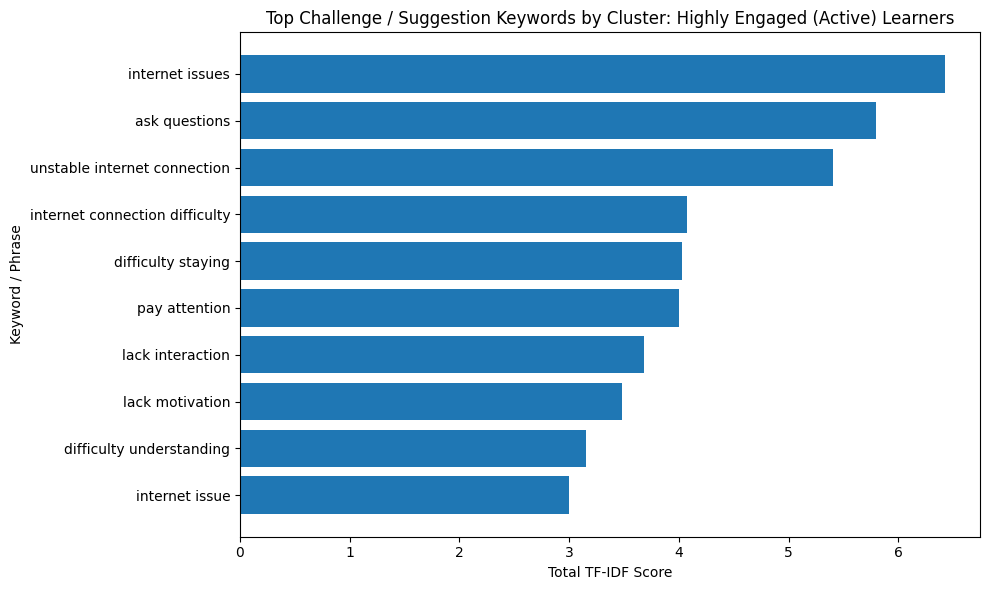

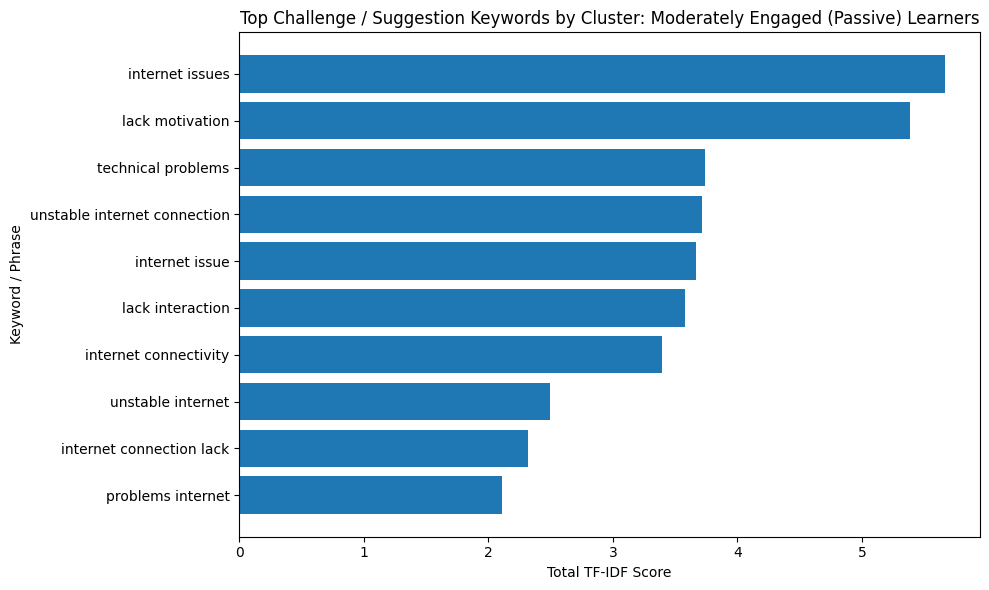

In [28]:
# =========================================================
# VISUALIZE TOP KEYWORDS BY CLUSTER
# =========================================================

def plot_keywords_by_cluster(cluster_keyword_df, title, top_n=10):
    if cluster_keyword_df.empty:
        print(f"No keyword data available for: {title}")
        return

    clusters = cluster_keyword_df["cluster_label"].dropna().unique()

    for cluster_label in clusters:
        plot_df = (
            cluster_keyword_df[
                cluster_keyword_df["cluster_label"] == cluster_label
            ]
            .sort_values("tfidf_score", ascending=False)
            .head(top_n)
            .sort_values("tfidf_score", ascending=True)
        )

        plt.figure(figsize=(10, 6))
        plt.barh(plot_df["keyword"], plot_df["tfidf_score"])
        plt.xlabel("Total TF-IDF Score")
        plt.ylabel("Keyword / Phrase")
        plt.title(f"{title}: {cluster_label}")
        plt.tight_layout()
        plt.show()


plot_keywords_by_cluster(
    cluster_strength_keywords,
    "Top Strength Keywords by Cluster",
    top_n=10
)

plot_keywords_by_cluster(
    cluster_challenge_keywords,
    "Top Challenge / Suggestion Keywords by Cluster",
    top_n=10
)

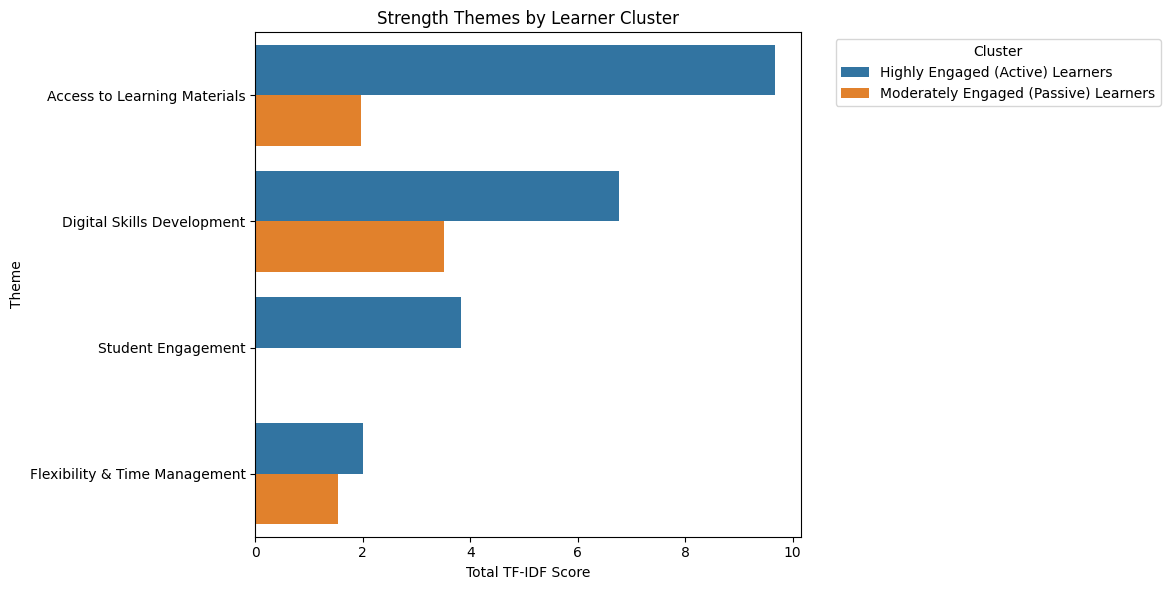

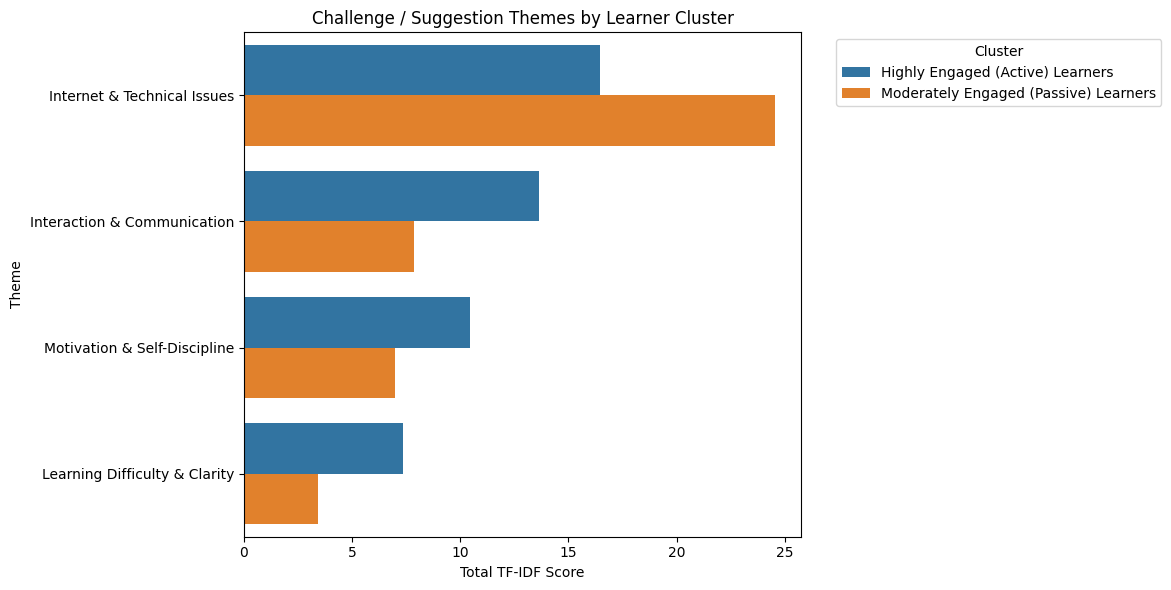

In [29]:
# =========================================================
# VISUALIZE THEMES BY CLUSTER
# =========================================================

def plot_themes_by_cluster(cluster_theme_df, title, top_n=10):
    if cluster_theme_df.empty:
        print(f"No cluster theme data available for: {title}")
        return

    plot_df = cluster_theme_df.copy()

    # Keep strongest themes overall to avoid overcrowded chart
    top_themes = (
        plot_df
        .groupby("theme")["total_score"]
        .sum()
        .sort_values(ascending=False)
        .head(top_n)
        .index
    )

    plot_df = plot_df[plot_df["theme"].isin(top_themes)]

    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=plot_df,
        x="total_score",
        y="theme",
        hue="cluster_label"
    )

    plt.xlabel("Total TF-IDF Score")
    plt.ylabel("Theme")
    plt.title(title)
    plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


plot_themes_by_cluster(
    cluster_strength_themes,
    "Strength Themes by Learner Cluster",
    top_n=10
)

plot_themes_by_cluster(
    cluster_challenge_themes,
    "Challenge / Suggestion Themes by Learner Cluster",
    top_n=10
)

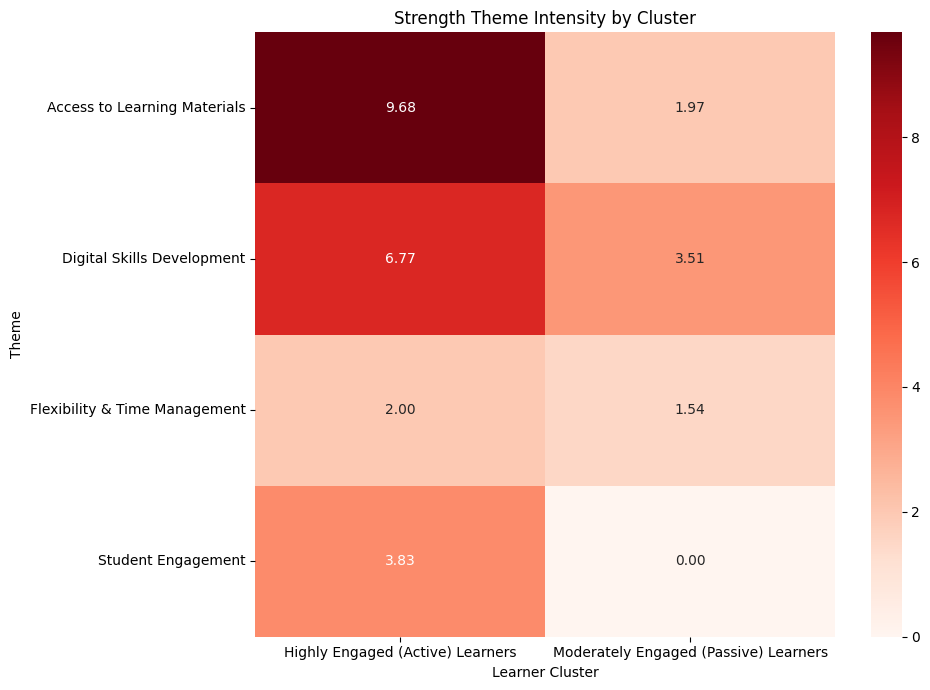

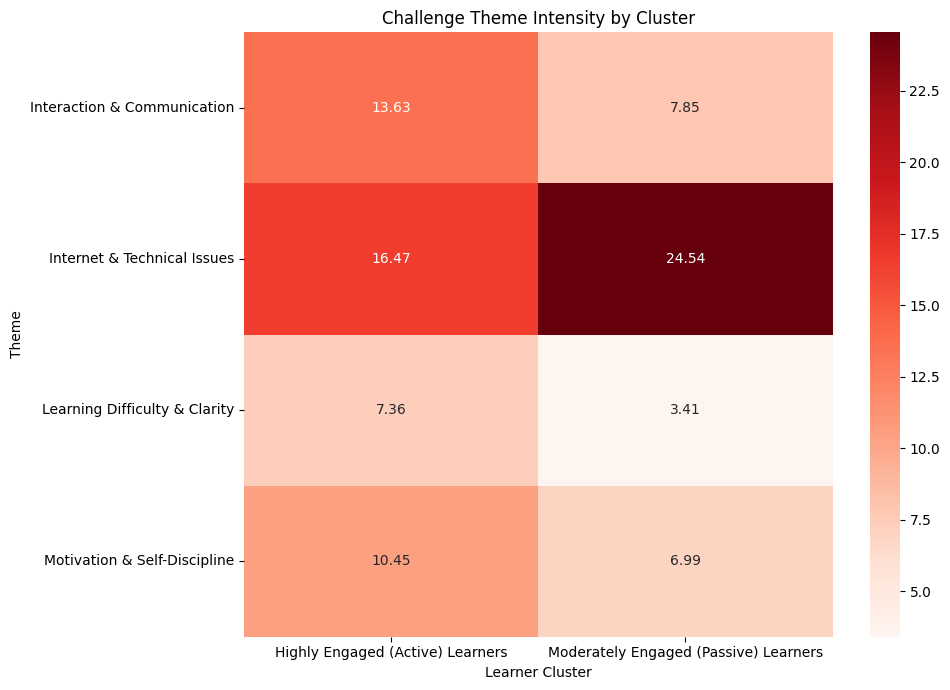

In [30]:
# =========================================================
# HEATMAP: THEMES BY CLUSTER
# =========================================================

def plot_theme_cluster_heatmap(cluster_theme_df, title):
    if cluster_theme_df.empty:
        print(f"No cluster theme data available for: {title}")
        return

    heatmap_df = cluster_theme_df.pivot_table(
        index="theme",
        columns="cluster_label",
        values="total_score",
        aggfunc="sum",
        fill_value=0
    )

    plt.figure(figsize=(10, 7))
    sns.heatmap(
        heatmap_df,
        annot=True,
        fmt=".2f",
        cmap="Reds"
    )

    plt.xlabel("Learner Cluster")
    plt.ylabel("Theme")
    plt.title(title)
    plt.tight_layout()
    plt.show()


plot_theme_cluster_heatmap(
    cluster_strength_themes,
    "Strength Theme Intensity by Cluster"
)

plot_theme_cluster_heatmap(
    cluster_challenge_themes,
    "Challenge Theme Intensity by Cluster"
)

# VADER SENTIMENT ANALYSIS

In [31]:

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

In [32]:
def get_vader_sentiment(text):
    if pd.isna(text) or str(text).strip() == "":
        return pd.Series({
            "neg": 0,
            "neu": 0,
            "pos": 0,
            "compound": 0,
            "sentiment_label": "neutral"
        })

    scores = analyzer.polarity_scores(str(text))
    compound = scores["compound"]

    if compound >= 0.05:
        label = "positive"
    elif compound <= -0.05:
        label = "negative"
    else:
        label = "neutral"

    return pd.Series({
        "neg": scores["neg"],
        "neu": scores["neu"],
        "pos": scores["pos"],
        "compound": compound,
        "sentiment_label": label
    })

In [34]:
# Strength / positive-aspect sentiment
strength_sentiment = (
    df["open_strengths_en"]
    .apply(get_vader_sentiment)
    .add_prefix("strength_")
)

# Challenge / suggestion sentiment
challenge_sentiment = (
    df["open_challenges_suggestions_en"]
    .apply(get_vader_sentiment)
    .add_prefix("challenge_")
)

df = pd.concat(
    [df, strength_sentiment, challenge_sentiment],
    axis=1
)

display(df.head())

,student_id,open_strengths,open_challenges_suggestions,student_segment,student_segment_label,cluster_label,open_strengths_lang,open_challenges_suggestions_lang,open_strengths_en,open_challenges_suggestions_en,...,strength_neg,strength_neu,strength_pos,strength_compound,strength_sentiment_label,challenge_neg,challenge_neu,challenge_pos,challenge_compound,challenge_sentiment_label
0,e20210686,Nothing,Nothing,2,Moderately Engaged (Passive) Learners,Highly Engaged (Active) Learners,en,en,Nothing,Nothing,...,0.000,1.000,0.000,0.0000,neutral,0.000,1.000,0.000,0.0000,neutral
1,e20241146,"Very good, excellent","No big challenge, i’m the best",1,Highly Engaged (Active) Learners,Moderately Engaged (Passive) Learners,en,en,"Very good, excellent","No big challenge, i’m the best",...,0.000,0.122,0.878,0.8004,positive,0.322,0.282,0.395,0.4172,positive
2,e20240609,Will try hard,Lack of self-discipline,1,Highly Engaged (Active) Learners,Moderately Engaged (Passive) Learners,en,en,Will try hard,Lack of self-discipline,...,0.412,0.588,0.000,-0.1027,negative,0.535,0.465,0.000,-0.3182,negative
3,e20240542,getting more experience,Discipline on daily studying,2,Moderately Engaged (Passive) Learners,Highly Engaged (Active) Learners,en,en,getting more experience,Discipline on daily studying,...,0.000,1.000,0.000,0.0000,neutral,0.000,1.000,0.000,0.0000,neutral
4,e20220287,Student could retrieve the lesson once they wa...,Add Ai assistance,2,Moderately Engaged (Passive) Learners,Highly Engaged (Active) Learners,en,en,Student could retrieve the lesson once they wa...,Add Ai assistance,...,0.000,0.874,0.126,0.0772,positive,0.000,1.000,0.000,0.0000,neutral


In [35]:
print("Strength sentiment distribution")
display(df["strength_sentiment_label"].value_counts())

print("Challenge / suggestion sentiment distribution")
display(df["challenge_sentiment_label"].value_counts())

Strength sentiment distribution


strength_sentiment_label
positive    383
neutral     145
negative     39
Name: count, dtype: int64

Challenge / suggestion sentiment distribution


challenge_sentiment_label
positive    213
negative    178
neutral     176
Name: count, dtype: int64

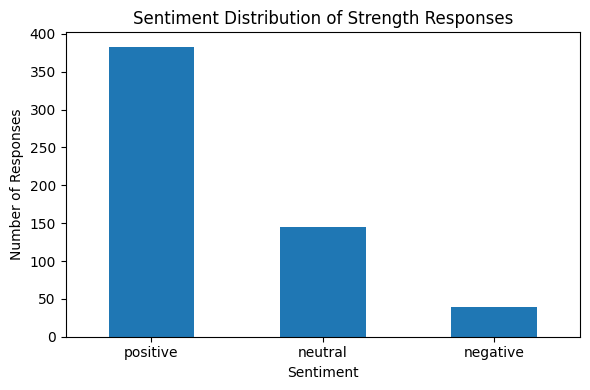

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
df["strength_sentiment_label"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution of Strength Responses")
plt.xlabel("Sentiment")
plt.ylabel("Number of Responses")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

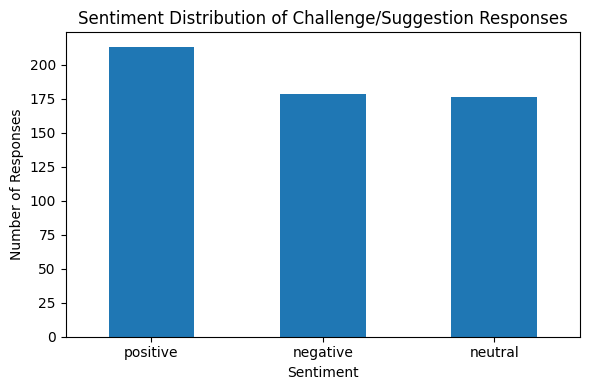

In [37]:
plt.figure(figsize=(6, 4))
df["challenge_sentiment_label"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution of Challenge/Suggestion Responses")
plt.xlabel("Sentiment")
plt.ylabel("Number of Responses")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [38]:
strength_sentiment_by_cluster = pd.crosstab(
    df["student_segment_label"],
    df["strength_sentiment_label"],
    normalize="index"
) * 100

challenge_sentiment_by_cluster = pd.crosstab(
    df["student_segment_label"],
    df["challenge_sentiment_label"],
    normalize="index"
) * 100

print("Strength sentiment by cluster (%)")
display(strength_sentiment_by_cluster.round(2))

print("Challenge / suggestion sentiment by cluster (%)")
display(challenge_sentiment_by_cluster.round(2))

Strength sentiment by cluster (%)


strength_sentiment_label,negative,neutral,positive
student_segment_label,,,
Highly Engaged (Active) Learners,5.51,24.06,70.43
Moderately Engaged (Passive) Learners,9.01,27.93,63.06


Challenge / suggestion sentiment by cluster (%)


challenge_sentiment_label,negative,neutral,positive
student_segment_label,,,
Highly Engaged (Active) Learners,33.04,28.99,37.97
Moderately Engaged (Passive) Learners,28.83,34.23,36.94


In [39]:
sentiment_cluster_summary = (
    df
    .groupby("student_segment_label")[
        ["strength_compound", "challenge_compound"]
    ]
    .mean()
    .reset_index()
)

display(sentiment_cluster_summary)

,student_segment_label,strength_compound,challenge_compound
0,Highly Engaged (Active) Learners,0.374236,0.061637
1,Moderately Engaged (Passive) Learners,0.312136,0.084515


_ Cluster 2 = more positive about benefits
_ Cluster 2 = also more critical about challenges
_ Cluster 1 = less expressive / more moderate

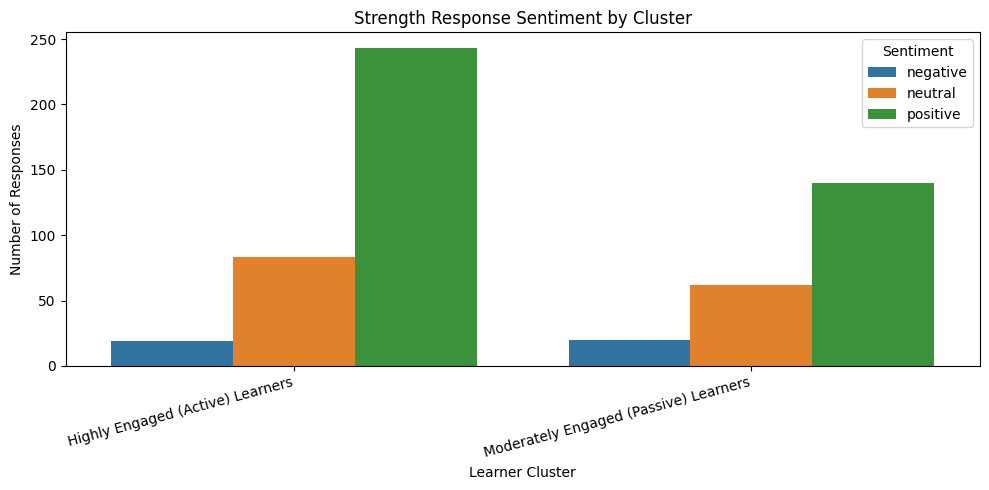

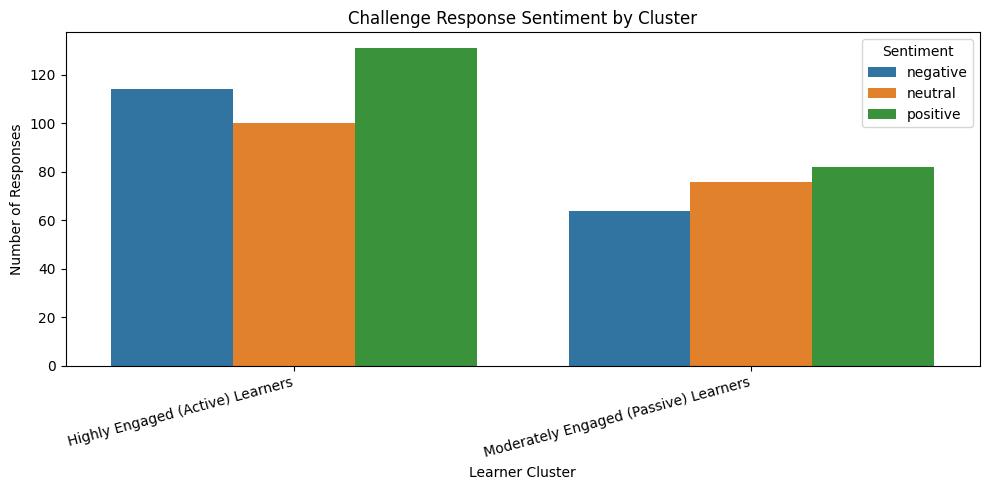

In [40]:
# =========================================================
# VISUALIZE SENTIMENT DISTRIBUTION BY CLUSTER
# =========================================================

strength_sentiment_plot = (
    df
    .groupby(["student_segment_label", "strength_sentiment_label"])
    .size()
    .reset_index(name="count")
)

challenge_sentiment_plot = (
    df
    .groupby(["student_segment_label", "challenge_sentiment_label"])
    .size()
    .reset_index(name="count")
)


plt.figure(figsize=(10, 5))
sns.barplot(
    data=strength_sentiment_plot,
    x="student_segment_label",
    y="count",
    hue="strength_sentiment_label"
)
plt.xlabel("Learner Cluster")
plt.ylabel("Number of Responses")
plt.title("Strength Response Sentiment by Cluster")
plt.xticks(rotation=15, ha="right")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))
sns.barplot(
    data=challenge_sentiment_plot,
    x="student_segment_label",
    y="count",
    hue="challenge_sentiment_label"
)
plt.xlabel("Learner Cluster")
plt.ylabel("Number of Responses")
plt.title("Challenge Response Sentiment by Cluster")
plt.xticks(rotation=15, ha="right")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

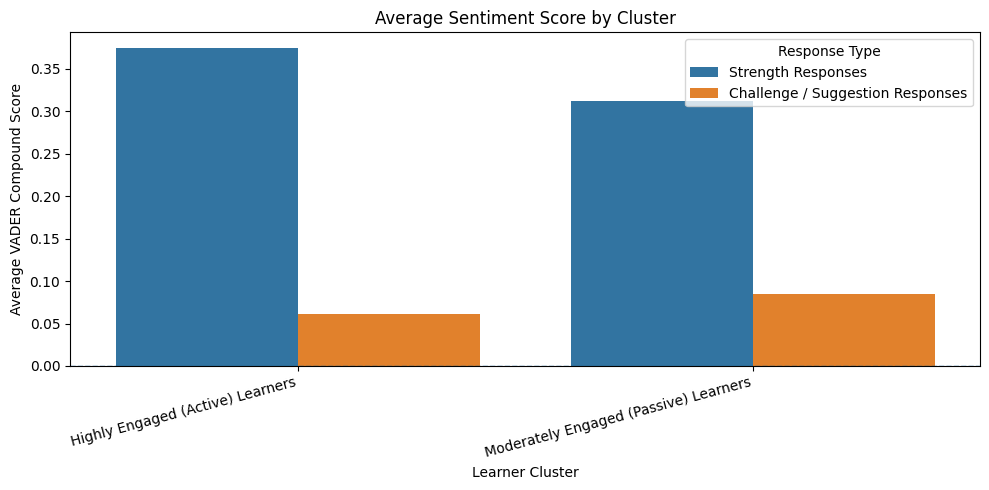

In [41]:
# =========================================================
# SENTIMENT COMPOUND SCORE BY CLUSTER
# =========================================================

sentiment_long = sentiment_cluster_summary.melt(
    id_vars="student_segment_label",
    value_vars=["strength_compound", "challenge_compound"],
    var_name="response_type",
    value_name="average_compound_score"
)

sentiment_long["response_type"] = sentiment_long["response_type"].replace({
    "strength_compound": "Strength Responses",
    "challenge_compound": "Challenge / Suggestion Responses"
})

plt.figure(figsize=(10, 5))
sns.barplot(
    data=sentiment_long,
    x="student_segment_label",
    y="average_compound_score",
    hue="response_type"
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Learner Cluster")
plt.ylabel("Average VADER Compound Score")
plt.title("Average Sentiment Score by Cluster")
plt.xticks(rotation=15, ha="right")
plt.legend(title="Response Type")
plt.tight_layout()
plt.show()

In [42]:
# =========================================================
# EXPORT STUDENT-LEVEL RECOMMENDATION FEATURES
# NLP TAGS + SEGMENT FALLBACK TAGS
# =========================================================

import os
import re
import json
import pandas as pd


# ---------------------------------------------------------
# 1. Text normalization
# ---------------------------------------------------------

def normalize_text_for_matching(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()
    text = text.replace("_", " ")
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text


def is_non_meaningful_response(text):
    text_norm = normalize_text_for_matching(text)

    non_meaningful = {
        "",
        "no",
        "none",
        "nothing",
        "no comment",
        "not sure",
        "no idea",
        "don t know",
        "dont know",
        "don t have",
        "dont have",
        "not yet",
        "n a",
        "na",
        "nil",
        "ok",
        "okay",
        "agree",
        "all good",
        "everything is good",
        "it already great",
        "nope",
        "math",
        "french",
        "coding",
        "sad",
        "uyu",
        "uu",
        "nuh uhh",
        "dunno yet"
    }

    return text_norm in non_meaningful


# ---------------------------------------------------------
# 2. Student-level theme detection
# ---------------------------------------------------------

def detect_themes(text, theme_map):
    """
    Detect themes from one student's cleaned response.
    """
    if is_non_meaningful_response(text):
        return []

    text_norm = normalize_text_for_matching(text)
    matched_themes = []

    for theme, keywords in theme_map.items():
        for keyword in keywords:
            keyword_norm = normalize_text_for_matching(keyword)

            if keyword_norm and keyword_norm in text_norm:
                matched_themes.append(theme)
                break

    return sorted(list(set(matched_themes)))


def themes_to_tags(themes):
    """
    Convert detected themes into recommendation tags.
    """
    tags = []

    for theme in themes:
        tag = theme_to_recommendation_map.get(theme)

        if tag is not None:
            tags.append(tag)

    return sorted(list(set(tags)))


# ---------------------------------------------------------
# 3. Create NLP-based themes and tags
# ---------------------------------------------------------

df["strength_themes"] = df["open_strengths_clean"].apply(
    lambda x: detect_themes(x, strength_theme_map)
)

df["challenge_themes"] = df["open_challenges_clean"].apply(
    lambda x: detect_themes(x, challenge_theme_map)
)

df["strength_tags"] = df["strength_themes"].apply(themes_to_tags)

df["challenge_tags"] = df["challenge_themes"].apply(themes_to_tags)

df["recommendation_tags"] = df.apply(
    lambda row: sorted(
        list(
            set(row["strength_tags"] + row["challenge_tags"])
        )
    ),
    axis=1
)


# ---------------------------------------------------------
# 4. Segment-based fallback tags
# ---------------------------------------------------------

def get_segment_default_tags(segment_label):
    """
    Segment fallback tags.
    Used only when NLP-based recommendation_tags are empty.
    """
    if pd.isna(segment_label):
        return []

    label = str(segment_label).lower()

    if "cluster 1" in label or "passive" in label or "moderately engaged" in label:
        return [
            "motivation",
            "interaction",
            "learning_support",
            "self_paced"
        ]

    if "cluster 2" in label or "active" in label or "highly engaged" in label:
        return [
            "content_access",
            "engagement",
            "digital_skill",
            "self_paced"
        ]

    return []


df["segment_default_tags"] = df["student_segment_label"].apply(
    get_segment_default_tags
)


def create_final_recommendation_tags(row):
    """
    Use NLP tags if available.
    If NLP tags are empty, use segment fallback tags.
    """
    nlp_tags = row["recommendation_tags"]
    fallback_tags = row["segment_default_tags"]

    if isinstance(nlp_tags, list) and len(nlp_tags) > 0:
        return sorted(list(set(nlp_tags)))

    return sorted(list(set(fallback_tags)))


df["final_recommendation_tags"] = df.apply(
    create_final_recommendation_tags,
    axis=1
)


# ---------------------------------------------------------
# 5. Rule-based recommendation text
# ---------------------------------------------------------

recommendation_rule_bank = {
    "tech_issue": {
        "title": "Improve technical access and reliability",
        "recommendation": "Provide stable internet access, offline materials, clear platform instructions, and technical support."
    },
    "motivation": {
        "title": "Support motivation and self-discipline",
        "recommendation": "Use weekly check-ins, reminders, progress tracking, and structured study schedules."
    },
    "interaction": {
        "title": "Increase interaction and communication",
        "recommendation": "Add Q&A sessions, group discussion, peer collaboration, and faster lecturer feedback."
    },
    "learning_support": {
        "title": "Improve clarity and learning support",
        "recommendation": "Provide clearer instructions, examples, recorded explanations, and step-by-step learning guides."
    },
    "learning_environment": {
        "title": "Improve learning resources and environment",
        "recommendation": "Organize materials clearly, update resources, improve study spaces, and support classroom comfort."
    },
    "workload_support": {
        "title": "Manage workload and assessment pressure",
        "recommendation": "Balance assignments, clarify deadlines, and align online tasks with in-person sessions."
    },
    "self_paced": {
        "title": "Support self-paced learning",
        "recommendation": "Provide recorded lessons, weekly learning paths, and materials students can review at their own pace."
    },
    "content_access": {
        "title": "Strengthen access to learning materials",
        "recommendation": "Upload slides, videos, references, exercises, and course materials early."
    },
    "digital_skill": {
        "title": "Develop digital learning skills",
        "recommendation": "Provide guidance on LMS tools, online resources, digital research, and educational technologies."
    },
    "engagement": {
        "title": "Increase learner engagement",
        "recommendation": "Use quizzes, games, practical tasks, discussions, and interactive activities."
    },
    "learning_effectiveness": {
        "title": "Improve learning effectiveness",
        "recommendation": "Combine online review materials with in-person explanation, practice, and feedback."
    }
}


def build_rule_based_recommendations(tags):
    recommendations = []

    for tag in tags:
        if tag in recommendation_rule_bank:
            recommendations.append({
                "tag": tag,
                "title": recommendation_rule_bank[tag]["title"],
                "recommendation": recommendation_rule_bank[tag]["recommendation"]
            })

    return recommendations


df["rule_based_recommendations"] = df["final_recommendation_tags"].apply(
    build_rule_based_recommendations
)


# ---------------------------------------------------------
# 6. Convert list/dict columns to JSON strings for CSV
# ---------------------------------------------------------

json_cols = [
    "strength_themes",
    "challenge_themes",
    "strength_tags",
    "challenge_tags",
    "recommendation_tags",
    "segment_default_tags",
    "final_recommendation_tags",
    "rule_based_recommendations"
]

for col in json_cols:
    df[col] = df[col].apply(
        lambda x: json.dumps(x, ensure_ascii=False)
    )


# ---------------------------------------------------------
# 7. Select final export columns
# ---------------------------------------------------------

recommendation_feature_cols = [
    "student_id",
    "student_segment",
    "student_segment_label",
    "cluster_label",

    "open_strengths_en",
    "open_challenges_suggestions_en",
    "open_strengths_clean",
    "open_challenges_clean",

    "strength_sentiment_label",
    "challenge_sentiment_label",
    "strength_compound",
    "challenge_compound",

    "strength_themes",
    "challenge_themes",
    "strength_tags",
    "challenge_tags",

    "recommendation_tags",
    "segment_default_tags",
    "final_recommendation_tags",
    "rule_based_recommendations"
]

recommendation_feature_cols = [
    col for col in recommendation_feature_cols
    if col in df.columns
]

student_recommendation_features = df[
    recommendation_feature_cols
].copy()


# ---------------------------------------------------------
# 8. Export CSV
# ---------------------------------------------------------

output_path = settings.root / "data" / "processed" / "student_recommendation_features.csv"

student_recommendation_features.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig"
)

print("Student recommendation feature dataset exported successfully.")
print(f"Saved to: {output_path}")
print(f"Shape: {student_recommendation_features.shape}")

display(student_recommendation_features.head(10))


Student recommendation feature dataset exported successfully.
Saved to: C:\Users\Tepy\Documents\tepy\Final Internship Docs\blended_learning\data\processed\student_recommendation_features.csv
Shape: (567, 20)


,student_id,student_segment,student_segment_label,cluster_label,open_strengths_en,open_challenges_suggestions_en,open_strengths_clean,open_challenges_clean,strength_sentiment_label,challenge_sentiment_label,strength_compound,challenge_compound,strength_themes,challenge_themes,strength_tags,challenge_tags,recommendation_tags,segment_default_tags,final_recommendation_tags,rule_based_recommendations
0,e20210686,2,Moderately Engaged (Passive) Learners,Highly Engaged (Active) Learners,Nothing,Nothing,nothing,nothing,neutral,neutral,0.0000,0.0000,[],[],[],[],[],"[""motivation"", ""interaction"", ""learning_suppor...","[""interaction"", ""learning_support"", ""motivatio...","[{""tag"": ""interaction"", ""title"": ""Increase int..."
1,e20241146,1,Highly Engaged (Active) Learners,Moderately Engaged (Passive) Learners,"Very good, excellent","No big challenge, i’m the best",very good excellent,no big challenge i m the best,positive,positive,0.8004,0.4172,"[""Learning Convenience & Effectiveness""]",[],"[""learning_effectiveness""]",[],"[""learning_effectiveness""]","[""content_access"", ""engagement"", ""digital_skil...","[""learning_effectiveness""]","[{""tag"": ""learning_effectiveness"", ""title"": ""I..."
2,e20240609,1,Highly Engaged (Active) Learners,Moderately Engaged (Passive) Learners,Will try hard,Lack of self-discipline,will try hard,lack of self discipline,negative,negative,-0.1027,-0.3182,[],"[""Motivation & Self-Discipline""]",[],"[""motivation""]","[""motivation""]","[""content_access"", ""engagement"", ""digital_skil...","[""motivation""]","[{""tag"": ""motivation"", ""title"": ""Support motiv..."
3,e20240542,2,Moderately Engaged (Passive) Learners,Highly Engaged (Active) Learners,getting more experience,Discipline on daily studying,getting more experience,discipline on daily studying,neutral,neutral,0.0000,0.0000,"[""Learning Convenience & Effectiveness""]","[""Motivation & Self-Discipline""]","[""learning_effectiveness""]","[""motivation""]","[""learning_effectiveness"", ""motivation""]","[""motivation"", ""interaction"", ""learning_suppor...","[""learning_effectiveness"", ""motivation""]","[{""tag"": ""learning_effectiveness"", ""title"": ""I..."
4,e20220287,2,Moderately Engaged (Passive) Learners,Highly Engaged (Active) Learners,Student could retrieve the lesson once they wa...,Add Ai assistance,student could retrieve the lesson once they wa...,add ai assistance,positive,neutral,0.0772,0.0000,"[""Access to Learning Materials""]",[],"[""content_access""]",[],"[""content_access""]","[""motivation"", ""interaction"", ""learning_suppor...","[""content_access""]","[{""tag"": ""content_access"", ""title"": ""Strengthe..."
5,e20210180,2,Moderately Engaged (Passive) Learners,Highly Engaged (Active) Learners,Innovate yourself with the technology world,Lack of resources and misinformation,innovate yourself with the technology world,lack of resources and misinformation,positive,negative,0.4939,-0.5574,"[""Digital Skills Development""]","[""Learning Resources & Environment""]","[""digital_skill""]","[""learning_environment""]","[""digital_skill"", ""learning_environment""]","[""motivation"", ""interaction"", ""learning_suppor...","[""digital_skill"", ""learning_environment""]","[{""tag"": ""digital_skill"", ""title"": ""Develop di..."
6,e20241245,1,Highly Engaged (Active) Learners,Moderately Engaged (Passive) Learners,Blended learning has many positive aspects. It...,The biggest challenges of blended learning are...,blended_learning has many positive aspects it ...,the biggest challenges of blended_learning are...,positive,positive,0.9484,0.4019,"[""Access to Learning Materials"", ""Digital Skil...","[""Interaction & Communication"", ""Internet & Te...","[""content_access"", ""digital_skill"", ""engagemen...","[""interaction"", ""learning_environment"", ""learn...","[""content_access"", ""digital_skill"", ""engagemen...","[""content_access"", ""engagement"", ""digital_skil...","[""content_access"", ""digital_skill"", ""engagemen..

In [43]:
def json_len(x):
    try:
        return len(json.loads(x))
    except Exception:
        return 0


print("Total students:", len(student_recommendation_features))

print(
    "Empty NLP recommendation_tags:",
    student_recommendation_features["recommendation_tags"]
    .apply(json_len)
    .eq(0)
    .sum()
)

print(
    "Empty final_recommendation_tags:",
    student_recommendation_features["final_recommendation_tags"]
    .apply(json_len)
    .eq(0)
    .sum()
)

Total students: 567
Empty NLP recommendation_tags: 60
Empty final_recommendation_tags: 0
